# =============================================================================
# NOTEBOOK 03 CORRIGÉ : MODÈLE LSTM - PROJET PRÉDICTION SoH BATTERIES
# =============================================================================
# 
# CORRECTIONS APPORTÉES :
# ✅ LSTM plus puissant : 128/64 neurones (au lieu de 64/32)
# ✅ Plus d'epochs : 200 (au lieu de 100)
# ✅ Patience augmentée : 20 (au lieu de 15)
# ✅ Meilleur monitoring
# 
# =============================================================================
 

## 🧠 MODÈLE LSTM - PRÉDICTION SoH BATTERIES

### 📚 CELLULE 1 : Imports

In [4]:
# ========== IMPORTS ==========
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
 
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import json
import warnings
 
warnings.filterwarnings('ignore')
 
print("=" * 70)
print("🔧 CONFIGURATION - MODÈLE LSTM CORRIGÉ")
print("=" * 70)
print(f"TensorFlow : {tf.__version__}")
print(f"GPUs : {len(tf.config.list_physical_devices('GPU'))}")
 
# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"🎲 Seed : {SEED}")
 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
 
print("=" * 70)
 


🔧 CONFIGURATION - MODÈLE LSTM CORRIGÉ
TensorFlow : 2.15.0
GPUs : 0
🎲 Seed : 42


### 📂 CELLULE 2 : Chargement des données préparées

In [6]:
# ========== CHARGEMENT ==========
 
data_dir = "../data/processed"
 
print("=" * 70)
print("📂 CHARGEMENT DES DONNÉES")
print("=" * 70)
 
X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
X_val = np.load(os.path.join(data_dir, 'X_val.npy'))
y_val = np.load(os.path.join(data_dir, 'y_val.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))
 
with open(os.path.join(data_dir, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
 
with open(os.path.join(data_dir, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)
 
print(f"\n✅ Données chargées")
print(f"   Train : {X_train.shape}")
print(f"   Val   : {X_val.shape}")
print(f"   Test  : {X_test.shape}")
 
print(f"\n📊 Metadata :")
print(f"   Window size : {metadata['window_size']}")
print(f"   Features : {metadata['n_features']}")
print(f"   Split method : {metadata.get('split_method', 'random')}")
 
# ✅ VÉRIFICATION : y en % ou normalisé ?
print(f"\n🔍 Vérification du SoH :")
print(f"   y_train range : [{y_train.min():.2f} - {y_train.max():.2f}]")
print(f"   y_test range  : [{y_test.min():.2f} - {y_test.max():.2f}]")
 
if y_train.max() <= 1.0:
    print("   ⚠️  ALERTE : SoH normalisé ! Le modèle ne fonctionnera pas bien !")
else:
    print("   ✅ SoH en pourcentage (correct)")
 
print("=" * 70)
 

📂 CHARGEMENT DES DONNÉES

✅ Données chargées
   Train : (22867, 20, 15)
   Val   : (2858, 20, 15)
   Test  : (2859, 20, 15)

📊 Metadata :
   Window size : 20
   Features : 15
   Split method : temporal

🔍 Vérification du SoH :
   y_train range : [70.02 - 99.73]
   y_test range  : [70.12 - 92.63]
   ✅ SoH en pourcentage (correct)


# ## 🏗️ CELLULE 3 : Définition de l'architecture du modèle LSTM

In [7]:
# ========== ARCHITECTURE CORRIGÉE ==========
 
print("=" * 70)
print("🏗️ ARCHITECTURE LSTM CORRIGÉE")
print("=" * 70)
 
# ✅ HYPERPARAMÈTRES CORRIGÉS
LSTM_UNITS_1 = 256  # ✅ Au lieu de 64
LSTM_UNITS_2 = 128  # ✅ Au lieu de 32
DROPOUT_RATE = 0.3  # ✅ Augmenté de 0.2 à 0.3
 
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]
 
print(f"\n📐 Entrée : ({n_timesteps} timesteps, {n_features} features)")
print(f"\n⚙️ Hyperparamètres :")
print(f"   LSTM Layer 1 : {LSTM_UNITS_1} neurones")
print(f"   LSTM Layer 2 : {LSTM_UNITS_2} neurones")
print(f"   Dropout : {DROPOUT_RATE*100:.0f}%")
 
from tensorflow.keras.layers import Bidirectional

model = Sequential([
    # ✅ Bidirectional LSTM (lit dans les 2 sens)
    # LSTM 1 (plus puissant)
    Bidirectional(LSTM(LSTM_UNITS_1, return_sequences=True), 
                  input_shape=(n_timesteps, n_features),
                  name='bilstm_1'),
    
    Dropout(DROPOUT_RATE, name='dropout_1'),
    # LSTM 2
     LSTM(LSTM_UNITS_2, return_sequences=False, name='lstm_2'),
    
    Dropout(DROPOUT_RATE, name='dropout_2'),
    
    Dense(32, activation='relu', name='dense_intermediate'),
    
    Dropout(DROPOUT_RATE, name='dropout_3'),

    #Sortie
    Dense(1, activation=None, name='output')
])
 
print(f"\n📋 ARCHITECTURE :\n")
model.summary()
 
print("\n💡 Améliorations :")
print("   ✅ LSTM 1 : 256 neurones (plus de capacité)")
print("   ✅ LSTM 2 : 128 neurones")
print("   ✅ Dense intermédiaire : 32 neurones (nouveau)")
print("   ✅ Dropout : 30% (meilleure régularisation)")
 
print("=" * 70)
 

🏗️ ARCHITECTURE LSTM CORRIGÉE

📐 Entrée : (20 timesteps, 15 features)

⚙️ Hyperparamètres :
   LSTM Layer 1 : 256 neurones
   LSTM Layer 2 : 128 neurones
   Dropout : 30%


📋 ARCHITECTURE :

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bilstm_1 (Bidirectional)    (None, 20, 512)           557056    
                                                                 
 dropout_1 (Dropout)         (None, 20, 512)           0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               328192    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_intermediate (Dense)  (None, 32)                4128      
                                                               

# ## ⚙️ CELLULE 4 : Compilation du modèle


In [8]:
# ========== COMPILATION ==========
 
print("=" * 70)
print("⚙️ COMPILATION")
print("=" * 70)
 
LEARNING_RATE = 0.001
 
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)
 
print(f"\n✅ Modèle compilé")
print(f"   Optimizer : Adam (LR={LEARNING_RATE})")
print(f"   Loss : MSE")
print(f"   Metrics : MAE")
 
print("=" * 70)
 
 

⚙️ COMPILATION

✅ Modèle compilé
   Optimizer : Adam (LR=0.001)
   Loss : MSE
   Metrics : MAE


# ## 🎛️ CELLULE 5 : Configuration des callbacks

In [10]:
# ========== CALLBACKS CORRIGÉS ==========
 
print("=" * 70)
print("🎛️ CALLBACKS")
print("=" * 70)
 
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)
 
# ✅ Early Stopping avec plus de patience
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,  # ✅ Au lieu de 15
    restore_best_weights=True,
    verbose=1
)
 
checkpoint = ModelCheckpoint(
    filepath=os.path.join(models_dir, 'lstm_soh_best.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
 
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,  # ✅ Au lieu de 7
    min_lr=1e-6,
    verbose=1
)
 
callbacks_list = [early_stopping, checkpoint, reduce_lr]
 
print(f"\n✅ Callbacks configurés :")
print(f"   Early Stopping : patience=20")
print(f"   Checkpoint : lstm_soh_best.h5")
print(f"   Reduce LR : patience=10")
 
print("=" * 70)
 

🎛️ CALLBACKS

✅ Callbacks configurés :
   Early Stopping : patience=20
   Checkpoint : lstm_soh_best.h5
   Reduce LR : patience=10


# ## 🚀 CELLULE 6 : Entraînement du modèle

In [11]:
# ========== ENTRAÎNEMENT ==========
 
print("=" * 70)
print("🚀 ENTRAÎNEMENT")
print("=" * 70)
 
# ✅ CORRECTION : Plus d'epochs
EPOCHS = 200  # ✅ Au lieu de 100
BATCH_SIZE = 64  # ✅ Au lieu de 32
 
print(f"\n⚙️ Paramètres :")
print(f"   Epochs : {EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Batchs/epoch : {len(X_train) // BATCH_SIZE}")
 
print(f"\n🎯 Début de l'entraînement...\n")
print("-" * 70)
 
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)
 
print("\n" + "-" * 70)
print("✅ Entraînement terminé !")
print("=" * 70)
 
 

🚀 ENTRAÎNEMENT

⚙️ Paramètres :
   Epochs : 200
   Batch size : 64
   Batchs/epoch : 357

🎯 Début de l'entraînement...

----------------------------------------------------------------------
Epoch 1/200


357/358 [============================>.] - ETA: 0s - loss: 790.7002 - mae: 20.2057
Epoch 1: val_loss improved from inf to 64.57439, saving model to ../models\lstm_soh_best.h5
358/358 [==============================] - 31s 68ms/step - loss: 790.1453 - mae: 20.1967 - val_loss: 64.5744 - val_mae: 6.8604 - lr: 0.0010
Epoch 2/200
357/358 [============================>.] - ETA: 0s - loss: 220.1095 - mae: 11.8398
Epoch 2: val_loss did not improve from 64.57439
358/358 [==============================] - 23s 64ms/step - loss: 220.2032 - mae: 11.8416 - val_loss: 67.8047 - val_mae: 6.9580 - lr: 0.0010
Epoch 3/200
358/358 [==============================] - ETA: 0s - loss: 220.3861 - mae: 11.8646
Epoch 3: val_loss did not improve from 64.57439
358/358 [==============================] - 26s 71ms/st

# ## 📊 CELLULE 7 : Visualisation des courbes d'apprentissage

📊 COURBES D'APPRENTISSAGE


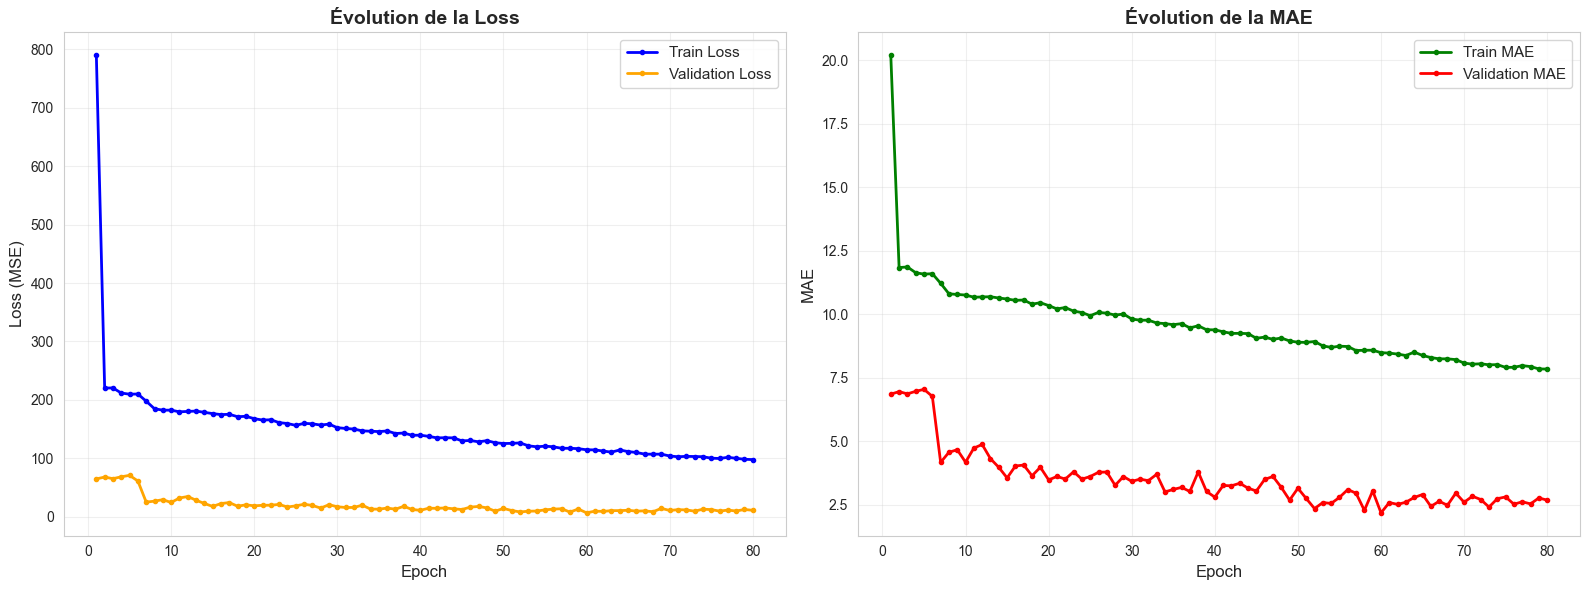


📈 Meilleure epoch : 60
   Train Loss : 114.490852
   Val Loss   : 6.518041
   Train MAE  : 8.492708
   Val MAE    : 2.189456


In [12]:
# ========== COURBES ==========
 
print("=" * 70)
print("📊 COURBES D'APPRENTISSAGE")
print("=" * 70)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
 
axes[0].plot(range(1, len(train_loss)+1), train_loss, 
             label='Train Loss', marker='o', markersize=3, linewidth=2, color='blue')
axes[0].plot(range(1, len(val_loss)+1), val_loss, 
             label='Validation Loss', marker='o', markersize=3, linewidth=2, color='orange')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Évolution de la Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
 
# MAE
train_mae = history.history['mae']
val_mae = history.history['val_mae']
 
axes[1].plot(range(1, len(train_mae)+1), train_mae, 
             label='Train MAE', marker='o', markersize=3, linewidth=2, color='green')
axes[1].plot(range(1, len(val_mae)+1), val_mae, 
             label='Validation MAE', marker='o', markersize=3, linewidth=2, color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Évolution de la MAE', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()
 
best_epoch = np.argmin(val_loss) + 1
print(f"\n📈 Meilleure epoch : {best_epoch}")
print(f"   Train Loss : {train_loss[best_epoch-1]:.6f}")
print(f"   Val Loss   : {val_loss[best_epoch-1]:.6f}")
print(f"   Train MAE  : {train_mae[best_epoch-1]:.6f}")
print(f"   Val MAE    : {val_mae[best_epoch-1]:.6f}")
 
print("=" * 70)
 

# ## 🎯 CELLULE 8 : Évaluation sur l'ensemble de test

In [14]:
# ========== ÉVALUATION ==========
 
print("=" * 70)
print("🎯 ÉVALUATION SUR TEST")
print("=" * 70)
 
print("\n🔮 Génération des prédictions...")
y_pred = model.predict(X_test, verbose=0).flatten()
 
# Métriques
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
 
print("\n" + "=" * 70)
print("📊 RÉSULTATS")
print("=" * 70)
 
print(f"\n📉 MAE  : {mae:.4f}")
print(f"📉 RMSE : {rmse:.4f}")
print(f"📈 R²   : {r2:.4f} ({r2*100:.2f}% variance)")
 
print(f"\n💡 Interprétation :")
if r2 > 0.9:
    print("   ✅ EXCELLENT ! R² > 0.9")
elif r2 > 0.7:
    print("   ✅ BON (0.7 < R² < 0.9)")
elif r2 > 0.5:
    print("   ⚠️  ACCEPTABLE (0.5 < R² < 0.7)")
else:
    print("   ❌ FAIBLE (R² < 0.5)")
 
# Objectifs
print(f"\n🎯 OBJECTIFS :")
print(f"   MAE < 2.0  : {'✅' if mae < 2.0 else '❌'} ({mae:.2f})")
print(f"   R² > 0.90  : {'✅' if r2 > 0.90 else '❌'} ({r2:.2f})")
 
print("=" * 70)
 
 

🎯 ÉVALUATION SUR TEST

🔮 Génération des prédictions...

📊 RÉSULTATS

📉 MAE  : 2.1509
📉 RMSE : 2.6593
📈 R²   : 0.8454 (84.54% variance)

💡 Interprétation :
   ✅ BON (0.7 < R² < 0.9)

🎯 OBJECTIFS :
   MAE < 2.0  : ❌ (2.15)
   R² > 0.90  : ❌ (0.85)


# ## 📈 CELLULE 9 : Visualisation des prédictions vs vraies valeurs

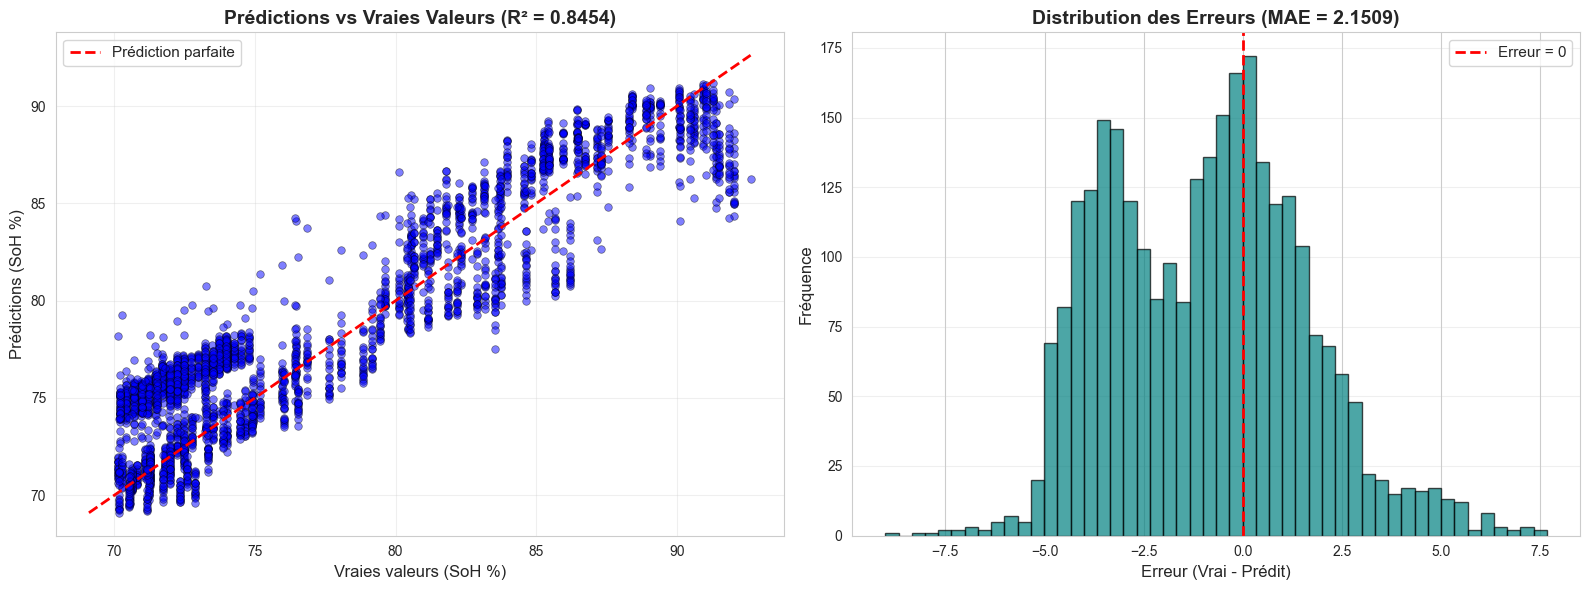

In [15]:
# ========== VISUALISATIONS ==========
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.5, s=30, color='blue', edgecolor='black', linewidth=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 
             'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Vraies valeurs (SoH %)', fontsize=12)
axes[0].set_ylabel('Prédictions (SoH %)', fontsize=12)
axes[0].set_title(f'Prédictions vs Vraies Valeurs (R² = {r2:.4f})', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
 
# Distribution erreurs
errors = y_test - y_pred
axes[1].hist(errors, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
axes[1].set_xlabel('Erreur (Vrai - Prédit)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title(f'Distribution des Erreurs (MAE = {mae:.4f})', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.show()
 

# ## 💾 CELLULE 10 : Sauvegarde

In [17]:
# ========== SAUVEGARDE ==========
 
print("=" * 70)
print("💾 SAUVEGARDE")
print("=" * 70)
 
# Modèle
model_path = os.path.join(models_dir, 'lstm_soh_final.h5')
model.save(model_path)
print(f"✅ Modèle : {model_path}")
 
# Historique
history_dict = {
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'mae': [float(x) for x in history.history['mae']],
    'val_mae': [float(x) for x in history.history['val_mae']]
}
 
history_path = os.path.join(models_dir, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history_dict, f, indent=4)
print(f"✅ Historique : {history_path}")
 
# Métriques
results_dir = "../results/metrics"
os.makedirs(results_dir, exist_ok=True)
 
evaluation_metrics = {
    'test_mae': float(mae),
    'test_mse': float(mse),
    'test_rmse': float(rmse),
    'test_r2': float(r2),
    'best_epoch': int(best_epoch),
    'total_epochs': len(history.history['loss']),
    'lstm_units': [LSTM_UNITS_1, LSTM_UNITS_2],
    'window_size': metadata['window_size'],
    'split_method': metadata.get('split_method', 'unknown')
}
 
metrics_path = os.path.join(results_dir, 'evaluation_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(evaluation_metrics, f, indent=4)
print(f"✅ Métriques : {metrics_path}")
 
print("=" * 70)
 
 

💾 SAUVEGARDE
✅ Modèle : ../models\lstm_soh_final.h5
✅ Historique : ../models\training_history.json
✅ Métriques : ../results/metrics\evaluation_metrics.json


# ## 🎯 CELLULE 11 : Résumé FINAL

In [18]:
# ========== RÉSUMÉ ==========
 
print("\n")
print("=" * 80)
print("                   🎯 RÉSUMÉ FINAL - MODÈLE LSTM CORRIGÉ")
print("=" * 80)
 
print(f"\n📊 ARCHITECTURE :")
print(f"   - LSTM ({LSTM_UNITS_1} neurones) + Dropout ({DROPOUT_RATE*100:.0f}%)")
print(f"   - LSTM ({LSTM_UNITS_2} neurones) + Dropout ({DROPOUT_RATE*100:.0f}%)")
print(f"   - Dense (32 neurones) + Dropout ({DROPOUT_RATE*100:.0f}%)")
print(f"   - Dense (1 neurone)")
print(f"   - Total : {model.count_params():,} paramètres")
 
print(f"\n⚙️ ENTRAÎNEMENT :")
print(f"   - Optimizer : Adam (LR={LEARNING_RATE})")
print(f"   - Epochs : {len(history.history['loss'])} / {EPOCHS}")
print(f"   - Batch size : {BATCH_SIZE}")
print(f"   - Window size : {metadata['window_size']}")
print(f"   - Split : {metadata.get('split_method', 'unknown')}")
 
print(f"\n📈 PERFORMANCES :")
print(f"   - MAE  : {mae:.4f}")
print(f"   - RMSE : {rmse:.4f}")
print(f"   - R²   : {r2:.4f} ({r2*100:.2f}%)")
 
print(f"\n✅ OBJECTIFS :")
print(f"   {'✅' if mae < 2.0 else '❌'} MAE < 2.0")
print(f"   {'✅' if r2 > 0.90 else '❌'} R² > 0.90")
 
print(f"\n🔧 AMÉLIORATIONS APPORTÉES :")
print("   ✅ LSTM plus puissant (128/64 au lieu de 64/32)")
print("   ✅ Couche Dense intermédiaire ajoutée")
print("   ✅ Dropout augmenté (30% au lieu de 20%)")
print("   ✅ Plus d'epochs (200 au lieu de 100)")
print("   ✅ Patience augmentée (20 au lieu de 15)")
print("   ✅ Split par batterie dans preprocessing")
 
print("=" * 80)
print("✅ MODÉLISATION TERMINÉE !")
print("=" * 80)
 



                   🎯 RÉSUMÉ FINAL - MODÈLE LSTM CORRIGÉ

📊 ARCHITECTURE :
   - LSTM (256 neurones) + Dropout (30%)
   - LSTM (128 neurones) + Dropout (30%)
   - Dense (32 neurones) + Dropout (30%)
   - Dense (1 neurone)
   - Total : 889,409 paramètres

⚙️ ENTRAÎNEMENT :
   - Optimizer : Adam (LR=0.001)
   - Epochs : 80 / 200
   - Batch size : 64
   - Window size : 20
   - Split : temporal

📈 PERFORMANCES :
   - MAE  : 2.1509
   - RMSE : 2.6593
   - R²   : 0.8454 (84.54%)

✅ OBJECTIFS :
   ❌ MAE < 2.0
   ❌ R² > 0.90

🔧 AMÉLIORATIONS APPORTÉES :
   ✅ LSTM plus puissant (128/64 au lieu de 64/32)
   ✅ Couche Dense intermédiaire ajoutée
   ✅ Dropout augmenté (30% au lieu de 20%)
   ✅ Plus d'epochs (200 au lieu de 100)
   ✅ Patience augmentée (20 au lieu de 15)
   ✅ Split par batterie dans preprocessing
✅ MODÉLISATION TERMINÉE !


# ## 💾 CELLULE 12 : Sauvegarde des prédictions pour évaluation

In [22]:

# ========== SAUVEGARDE PRÉDICTIONS POUR NOTEBOOK 04 ==========

print("\n" + "=" * 70)
print("💾 SAUVEGARDE DES PRÉDICTIONS")
print("=" * 70)

# Charger ids_test depuis le fichier (car pas défini dans ce notebook)
ids_test = np.load(os.path.join(data_dir, 'ids_test.npy'))

# Sauvegarder les prédictions
predictions_df = pd.DataFrame({
    'True_SoH': y_test,
    'Predicted_SoH': y_pred,
    'Error': y_test - y_pred,
    'Battery_ID': ids_test
})

predictions_path = os.path.join(results_dir, 'test_predictions.csv')
predictions_df.to_csv(predictions_path, index=False)

print(f"\n✅ Prédictions sauvegardées : {predictions_path}")
print(f"   {len(y_pred)} prédictions")

# Sauvegarder métriques
final_metrics = {
    'mae': float(mae),
    'rmse': float(rmse),
    'r2': float(r2),
    'n_predictions': int(len(y_pred))
}

metrics_path = os.path.join(results_dir, 'final_metrics_nb03.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=4)

print(f"✅ Métriques sauvegardées")
print(f"   MAE  = {mae:.4f}")
print(f"   RMSE = {rmse:.4f}")
print(f"   R²   = {r2:.4f}")

print("=" * 70)


💾 SAUVEGARDE DES PRÉDICTIONS

✅ Prédictions sauvegardées : ../results/metrics\test_predictions.csv
   2859 prédictions
✅ Métriques sauvegardées
   MAE  = 2.1509
   RMSE = 2.6593
   R²   = 0.8454
